# Approximate String Matching — Comprehensive Comparative Analysis

**CSE 317: Algorithms — Design and Analysis (Spring 2026)**  
Group: Khalid, Muskan, Kashish, Abdullah

Empirical comparison of the four algorithms our group implemented for the
*approximate string matching* problem (find every occurrence of pattern `P` in
text `T` with at most `k` errors, where an error is one insertion, deletion,
or substitution).

| Member   | Algorithm           | Paradigm                | Optimality |
|----------|---------------------|-------------------------|------------|
| Khalid   | Recursive Brute Force | Branch-and-Bound      | Exact      |
| Kashish  | Sellers'             | Dynamic Programming    | Exact      |
| Muskan   | Pigeonhole Filter    | Divide-and-Conquer     | Exact      |
| Abdullah | Seed-and-Extend      | Greedy / Approximation | Approximate (Hamming) |

All four algorithms are bundled in a single C++ binary (`bench.exe`) so the
comparison is unbiased: same compiler, same machine, same input files, same
wall-clock timer.

## Test plan

| # | Experiment | Why |
|---|------------|-----|
| 1 | **Eight input families** at fixed (n, m, k) with **5 random seeds** | Speed by input *structure*, with error bars |
| 2 | **Scaling with n**, faceted across all 8 families | Empirical complexity growth |
| 3 | **Scaling with m**, 5 seeds | Pattern-length sensitivity |
| 4 | **Scaling with k**, extended to k=16 | The most diagnostic axis |
| 5 | **Alphabet (σ) sweep** at fixed (n, m, k) | Isolates alphabet effect |
| 6 | **Edge-case suite** | Robustness: empty P, m>n, k≥m, no-match, P at start/end, P=T |
| 7 | **Algorithm-specific worst cases** | One adversarial input per algorithm |
| 8 | **Accuracy** (precision/recall vs Sellers') across all sweeps | Approximation tradeoff |
| 9 | **Theoretical vs empirical** complexity fit | Validates Table 1 of the project doc |
| 10 | **Leaderboard + discussion** | Final summary |

## 1. Setup and compilation

In [1]:
import os, sys, subprocess, random, string, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT      = Path('.').resolve()
BENCH_SRC = ROOT / 'bench.cpp'
BENCH_EXE = ROOT / ('bench.exe' if os.name == 'nt' else 'bench')
DATA_DIR  = ROOT / 'data';     DATA_DIR.mkdir(exist_ok=True)
OUT_DIR   = ROOT / 'results';  OUT_DIR.mkdir(exist_ok=True)
FIG_DIR   = ROOT / 'figures';  FIG_DIR.mkdir(exist_ok=True)

rc = subprocess.run(['g++','-std=c++17','-O2',str(BENCH_SRC),'-o',str(BENCH_EXE)],
                    capture_output=True, text=True)
print(rc.stdout, rc.stderr)
assert BENCH_EXE.exists(), 'bench failed to build'
print('bench.exe ready ->', BENCH_EXE)

ALGOS = ['brute','sellers','pigeonhole','seed']
ALGO_LABELS = {'brute':'Brute Force (Khalid)','sellers':"Sellers' DP (Kashish)",
               'pigeonhole':'Pigeonhole D&C (Muskan)','seed':'Seed-and-Extend (Abdullah)'}
ALGO_COLOR  = {'brute':'#d62728','sellers':'#1f77b4','pigeonhole':'#2ca02c','seed':'#ff7f0e'}
SEEDS = [42, 7, 1729, 31337, 271828]   # 5 fixed seeds → reproducible ± std-err

 
bench.exe ready -> D:\C++ Projects\DAA project\benchmark\bench.exe


## 2. Input generators (8 families)

We expand from 6 to **8 families** by adding two semi-real corpora:

- **`real_dna`** — Markov chain over DNA dinucleotides using *E. coli K-12*-like
  transition probabilities (≈50.8 % GC content, asymmetric CG dip, AT-rich runs).
  This is a standard way to generate a realistic-looking genome offline.
- **`real_english`** — A public-domain Shakespeare passage (Hamlet, *To be, or
  not to be*) tiled to the requested length. Real natural-language statistics
  (word boundaries, common letters, punctuation).

In [2]:
# ---- Synthetic families -----------------------------------------------------
def gen_text(family, n, rng):
    if family == 'dna':
        return ''.join(rng.choices('ACGT', k=n))
    if family == 'english':
        return ''.join(rng.choices(string.ascii_lowercase, k=n))
    if family == 'binary':
        return ''.join(rng.choices('01', k=n))
    if family == 'repetitive':
        s = list('A' * n)
        for _ in range(max(1, n // 200)):
            s[rng.randrange(n)] = 'T'
        return ''.join(s)
    if family == 'low_entropy_dna':
        return ''.join(rng.choices('ACGT', weights=[40,10,10,40], k=n))
    if family == 'adversarial':
        motif = 'ACGTACGTACGTACGT'
        s = list(rng.choices('ACGT', k=n))
        for _ in range(max(1, n // (len(motif)*4))):
            pos = rng.randrange(0, max(1, n - len(motif)))
            mu  = list(motif); mu[rng.randrange(len(motif))] = rng.choice('ACGT')
            s[pos:pos+len(motif)] = mu
        return ''.join(s)
    if family == 'real_dna':
        return markov_dna(n, rng)
    if family == 'real_english':
        return tile_shakespeare(n)
    raise ValueError(family)

def alphabet(family):
    return {'dna':'ACGT','english':string.ascii_lowercase,'binary':'01',
            'repetitive':'AT','low_entropy_dna':'ACGT','adversarial':'ACGT',
            'real_dna':'ACGT','real_english':None}[family]

# ---- Markov DNA (E. coli-like dinucleotide transitions) ---------------------
# Approximate published E. coli K-12 dinucleotide frequencies.
MARKOV_DNA = {
    'A': {'A':0.30,'C':0.18,'G':0.21,'T':0.31},
    'C': {'A':0.27,'C':0.27,'G':0.21,'T':0.25},
    'G': {'A':0.23,'C':0.32,'G':0.27,'T':0.18},
    'T': {'A':0.16,'C':0.23,'G':0.30,'T':0.31},
}
def markov_dna(n, rng):
    cur = rng.choice('ACGT')
    out = [cur]
    for _ in range(n - 1):
        d = MARKOV_DNA[cur]
        cur = rng.choices(list(d), weights=list(d.values()))[0]
        out.append(cur)
    return ''.join(out)

# ---- Shakespeare seed (public domain, Hamlet III.i) -------------------------
SHAKESPEARE = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms "
    "against a sea of troubles and by opposing end them to die to sleep no "
    "more and by a sleep to say we end the heart ache and the thousand natural "
    "shocks that flesh is heir to tis a consummation devoutly to be wished to "
    "die to sleep to sleep perchance to dream ay there is the rub for in that "
    "sleep of death what dreams may come when we have shuffled off this mortal "
    "coil must give us pause there is the respect that makes calamity of so "
    "long life for who would bear the whips and scorns of time the oppressors "
    "wrong the proud mans contumely the pangs of despised love the laws delay "
    "the insolence of office and the spurns that patient merit of the unworthy "
    "takes when he himself might his quietus make with a bare bodkin who would "
    "these fardels bear to grunt and sweat under a weary life but that the "
    "dread of something after death the undiscovered country from whose bourn "
    "no traveller returns puzzles the will and makes us rather bear those ills "
    "we have than fly to others that we know not of thus conscience does make "
    "cowards of us all and thus the native hue of resolution is sicklied oer "
    "with the pale cast of thought and enterprises of great pith and moment "
    "with this regard their currents turn awry and lose the name of action")
def tile_shakespeare(n):
    reps = (n // len(SHAKESPEARE)) + 1
    return (SHAKESPEARE * reps)[:n]

FAMILIES_ALL = ['dna','english','binary','repetitive','low_entropy_dna',
                'adversarial','real_dna','real_english']
for fam in FAMILIES_ALL:
    t = gen_text(fam, 80, random.Random(42))
    print(f'{fam:18s} | {t[:80]}')

dna                | GACAGGTACAAGAAGGAGTATGCATCAATGTGGTCGTGTGGAACAAACGCCACTGGAGACTGGGTTAACCATTCGCTCCA
english            | qahftrxckafnafqofpvausieyiccwpusnzjovqwpsbfhcgchqjjfgyqpesejzqorvufaigfywirkxlgg
binary             | 10001110000100110110110010001111110111111000000010000111010011111100000110101000
repetitive         | AAAAAAAAAAAAAATAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
low_entropy_dna    | TAAATTTACAAGAATGAGTATTAATAAATTTTGTAGTTTGTAAAAAAATAAAATTTATAATTGTTTAAAAATTATATCAA
adversarial        | GACAGGTACAAGAAGGAGTATGCATCAATGTGGACGTACGTACGTTCGTCCACTGGAGACTGGGTTAACCATTCGCTCCA
real_dna           | AAAATGTACAAGAAGCAGGATTCATCAATGGGCTCGTGTGGAAAAAAAGCCAATGGATCCTGGGTTCACAATTCGCTGCA
real_english       | to be or not to be that is the question whether tis nobler in the mind to suffer


In [3]:
def plant_pattern(text, m, k, family, rng):
    """Take a random substring of length m, then inject up to k random edits."""
    n = len(text)
    if m >= n: return text[:max(1,m)], 0
    pos = rng.randrange(0, n - m)
    pat = list(text[pos:pos+m])
    alpha = alphabet(family)
    if alpha is None:                              # real_english uses observed alphabet
        alpha = ''.join(sorted(set(text)))
    for _ in range(k):
        op = rng.choice(['sub','ins','del']) if len(pat) > 1 else 'sub'
        i = rng.randrange(len(pat))
        if op == 'sub':
            choices = [c for c in alpha if c != pat[i]]
            if choices: pat[i] = rng.choice(choices)
        elif op == 'ins':
            pat.insert(i, rng.choice(alpha))
        else:
            pat.pop(i)
    return ''.join(pat), pos

## 3. Benchmark runner with multi-seed averaging

For each (family, n, m, k), we draw inputs from `len(SEEDS)` independent random
seeds. Within each seed we take the **best of 3 runs** to dampen OS jitter,
then we report **mean ± standard error** across seeds.

In [4]:
def write_text(p, s):
    p.write_text(s, encoding='ascii', errors='replace'); return p

def run_one(algo, text_path, pattern_path, k, timeout=60):
    try:
        r = subprocess.run([str(BENCH_EXE), algo, str(text_path), str(pattern_path), str(k)],
                           capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        return None
    if r.returncode != 0:
        raise RuntimeError(f'{algo} failed: {r.stderr}')
    lines = r.stdout.strip().splitlines()
    head  = lines[0].split(',')
    starts = [int(x) for x in lines[1].split(',')] if len(lines) > 1 and lines[1] else []
    return dict(algo=head[0], n=int(head[1]), m=int(head[2]), k=int(head[3]),
                matches=int(head[4]), us=int(head[5]), starts=starts)

def algo_is_safe(algo, n, m, k):
    if algo == 'brute':
        if k >= 4: return False
        if n * (3 ** max(0,k)) > 30_000_000: return False
        if n > 50_000: return False
    return True

def bench_case(text, pattern, k, family, label, repeats=3, timeout=45,
               m_req=None, k_req=None):
    """Run all 4 algos on one (text, pattern, k) and return list-of-dicts.
       m_req/k_req record the *requested* parameters (which may differ from
       the actual m after random insertions/deletions in pattern planting).
       Group analyses always use the requested parameters.
    """
    n, m = len(text), len(pattern)
    if m_req is None: m_req = m
    if k_req is None: k_req = k
    tT = write_text(DATA_DIR/'_T.txt', text)
    tP = write_text(DATA_DIR/'_P.txt', pattern)
    rows = []
    for algo in ALGOS:
        base = dict(label=label, family=family, algo=algo,
                    n=n, m=m, k=k, m_req=m_req, k_req=k_req)
        if not algo_is_safe(algo, n, m, k):
            rows.append({**base, 'us':np.nan, 'matches':np.nan, 'starts':[], 'skipped':True})
            continue
        best, last = math.inf, None
        for _ in range(repeats):
            r = run_one(algo, tT, tP, k, timeout=timeout)
            if r is None: best, last = None, None; break
            last = r; best = min(best, r['us'])
        if last is None:
            rows.append({**base, 'us':np.nan, 'matches':np.nan, 'starts':[], 'skipped':True})
        else:
            rows.append({**base, 'us':best, 'matches':last['matches'],
                         'starts':last['starts'], 'skipped':False})
    return rows

def bench_seeds(family, n, m, k, seeds=SEEDS, repeats=3):
    """Run all 4 algos across multiple seeds for one (family,n,m,k).
       The *requested* m,k are stored as m_req/k_req in every row, so
       multi-seed aggregation is robust to plant_pattern changing length.
    """
    rows = []
    for s in seeds:
        rng = random.Random(s)
        text = gen_text(family, n, rng)
        pat, _ = plant_pattern(text, m, k, family, rng)
        for r in bench_case(text, pat, k, family, label=f'{family}_s{s}',
                            repeats=repeats, m_req=m, k_req=k):
            r['seed'] = s; rows.append(r)
    return rows

def aggregate(df):
    """Mean / std / count across seeds, grouped on the *requested* parameters."""
    g = df.dropna(subset=['us']).groupby(['family','n','m_req','k_req','algo'])
    return g['us'].agg(['mean','std','count']).reset_index().rename(
        columns={'mean':'us_mean','std':'us_std','count':'n_seeds'})

# Smoke test
smoke = bench_seeds('dna', 5_000, 16, 2, seeds=[42], repeats=2)
pd.DataFrame(smoke)[['family','algo','n','m','m_req','k','k_req','us','matches']]

,family,algo,n,m,m_req,k,k_req,us,matches
0,dna,brute,5000,14,16,2,2,997,3
1,dna,sellers,5000,14,16,2,2,0,4
2,dna,pigeonhole,5000,14,16,2,2,0,2
3,dna,seed,5000,14,16,2,2,0,0


## 4. Experiment 1 — Eight input families × 5 seeds, fixed (n, m, k)

Same `(n=5000, m=16, k=2)` for every family so differences are attributable
purely to input *structure*. Bars show mean over 5 seeds, error bars are ±1
standard error.

In [5]:
rows_e1 = []
for fam in FAMILIES_ALL:
    rows_e1.extend(bench_seeds(fam, 5_000, 16, 2, seeds=SEEDS))
df_e1 = pd.DataFrame(rows_e1)
df_e1.to_csv(OUT_DIR/'exp1_families.csv', index=False)
agg_e1 = aggregate(df_e1)
agg_e1.to_csv(OUT_DIR/'exp1_families_agg.csv', index=False)
agg_e1

,family,n,m_req,k_req,algo,us_mean,us_std,n_seeds
0,adversarial,5000,16,2,brute,199.4,445.871955,5
1,adversarial,5000,16,2,pigeonhole,0.0,0.000000,5
2,adversarial,5000,16,2,seed,0.0,0.000000,5
3,adversarial,5000,16,2,sellers,0.0,0.000000,5
4,binary,5000,16,2,brute,609.6,560.011875,5
5,binary,5000,16,2,pigeonhole,1161.6,793.832035,5
6,binary,5000,16,2,seed,193.2,432.008333,5
7,binary,5000,16,2,sellers,199.8,446.766382,5
8,dna,5000,16,2,brute,199.8,446.766382,5
9,dna,5000,16,2,pigeonhole,0.0,0.000000,5


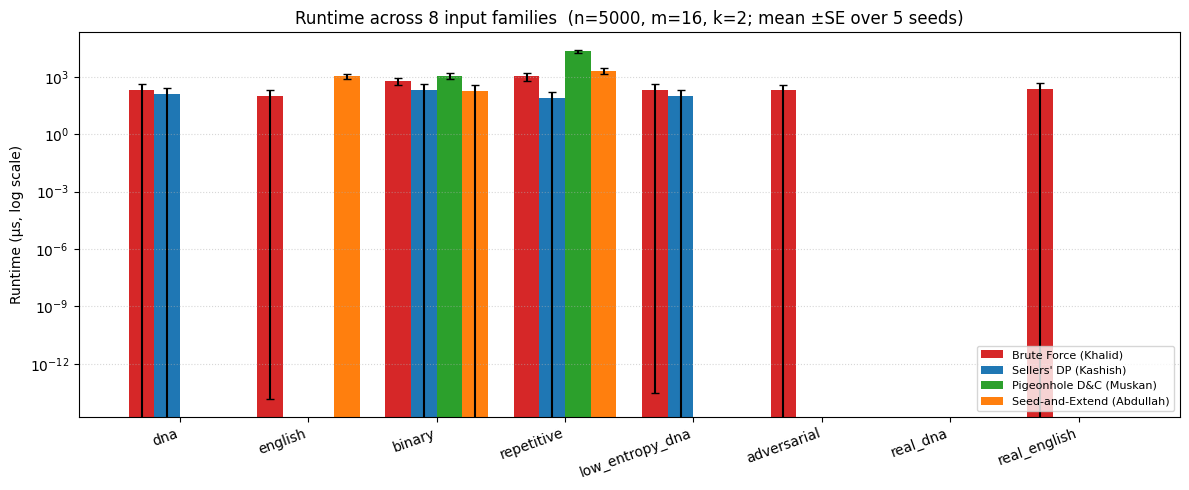

In [6]:
fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(FAMILIES_ALL)); width = 0.2
for i, a in enumerate(ALGOS):
    sub = agg_e1[agg_e1.algo==a].set_index('family').reindex(FAMILIES_ALL)
    se  = sub.us_std / np.sqrt(sub.n_seeds.replace(0,1))
    ax.bar(x + (i-1.5)*width, sub.us_mean.fillna(0), width,
           yerr=se.fillna(0), label=ALGO_LABELS[a], color=ALGO_COLOR[a], capsize=3)
ax.set_xticks(x); ax.set_xticklabels(FAMILIES_ALL, rotation=20, ha='right')
ax.set_yscale('log'); ax.set_ylabel('Runtime (μs, log scale)')
ax.set_title('Runtime across 8 input families  (n=5000, m=16, k=2; mean ±SE over 5 seeds)')
ax.legend(fontsize=8); ax.grid(True, axis='y', ls=':', alpha=0.5)
plt.tight_layout(); plt.savefig(FIG_DIR/'exp1_families.png', dpi=140); plt.show()

## 5. Experiment 2 — Scaling with text length `n`, faceted by family

`n` swept on a log grid; `m=20`, `k=2` fixed. Now repeated **for every family**
so we can see how alphabet/structure changes the constants. Min `n` is 10k so
the timer floor (~µs) doesn't pollute the power-law fit.

In [7]:
ns = [10_000, 20_000, 50_000, 100_000, 200_000]
m_e2, k_e2 = 20, 2
rows_e2 = []
for fam in FAMILIES_ALL:
    for n in ns:
        rows_e2.extend(bench_seeds(fam, n, m_e2, k_e2, seeds=SEEDS[:3]))
df_e2 = pd.DataFrame(rows_e2)
df_e2.to_csv(OUT_DIR/'exp2_scaling_n.csv', index=False)
agg_e2 = aggregate(df_e2)
agg_e2.head()

,family,n,m_req,k_req,algo,us_mean,us_std,n_seeds
0,adversarial,10000,20,2,brute,0.000000,0.000000,3
1,adversarial,10000,20,2,pigeonhole,231.000000,400.103737,3
2,adversarial,10000,20,2,seed,0.000000,0.000000,3
3,adversarial,10000,20,2,sellers,291.000000,504.026785,3
4,adversarial,20000,20,2,brute,2825.333333,2446.862753,3


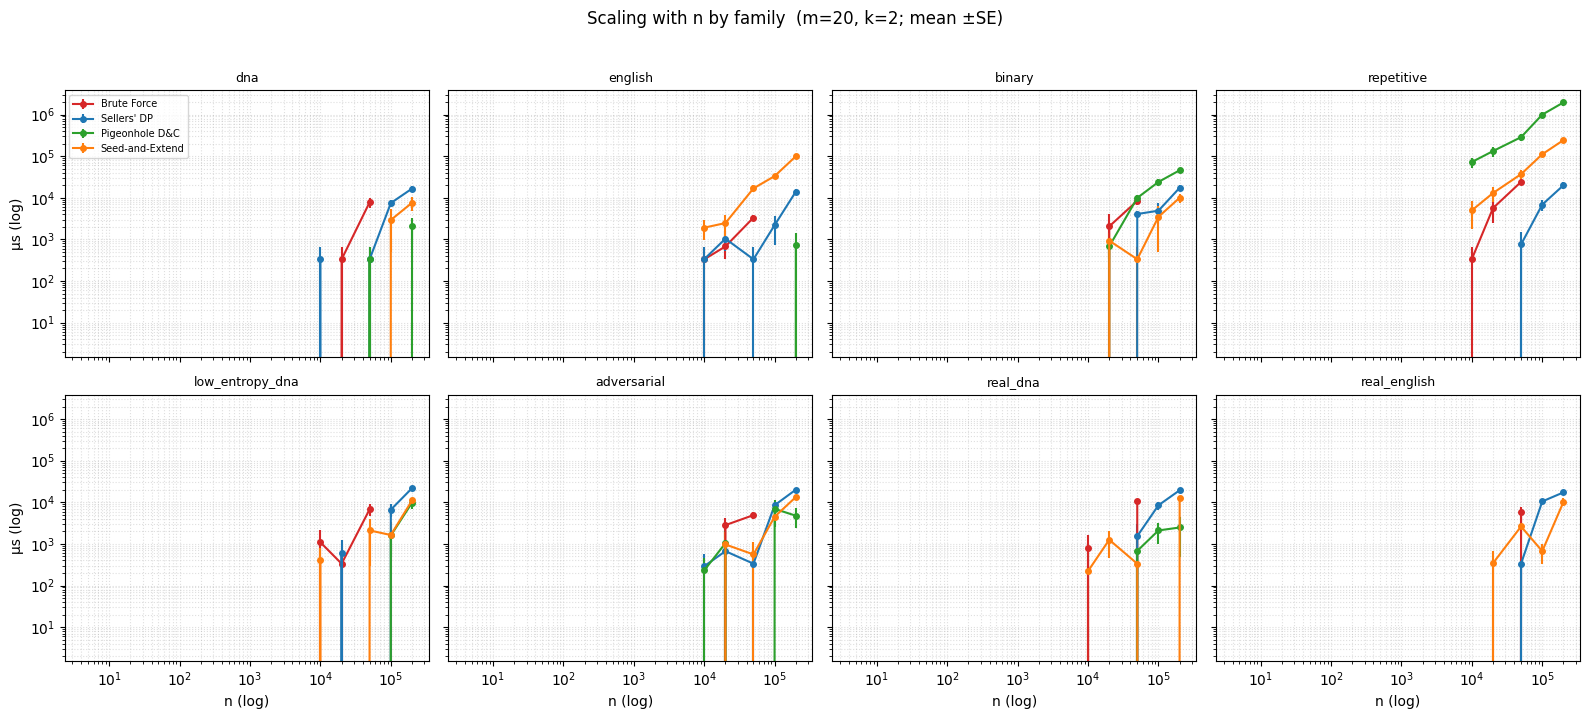

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
for ax, fam in zip(axes.flat, FAMILIES_ALL):
    for a in ALGOS:
        sub = agg_e2[(agg_e2.family==fam) & (agg_e2.algo==a)].sort_values('n')
        if sub.empty: continue
        se = sub.us_std / np.sqrt(sub.n_seeds.replace(0,1))
        ax.errorbar(sub.n, sub.us_mean, yerr=se, marker='o', ms=4,
                    label=ALGO_LABELS[a].split(' (')[0], color=ALGO_COLOR[a])
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(fam, fontsize=9)
    ax.grid(True, which='both', ls=':', alpha=0.4)
for ax in axes[-1, :]: ax.set_xlabel('n (log)')
for ax in axes[:, 0]:  ax.set_ylabel('μs (log)')
axes[0,0].legend(fontsize=7, loc='upper left')
fig.suptitle(f'Scaling with n by family  (m={m_e2}, k={k_e2}; mean ±SE)', y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR/'exp2_scaling_n.png', dpi=140, bbox_inches='tight')
plt.show()

## 6. Experiment 3 — Scaling with pattern length `m`

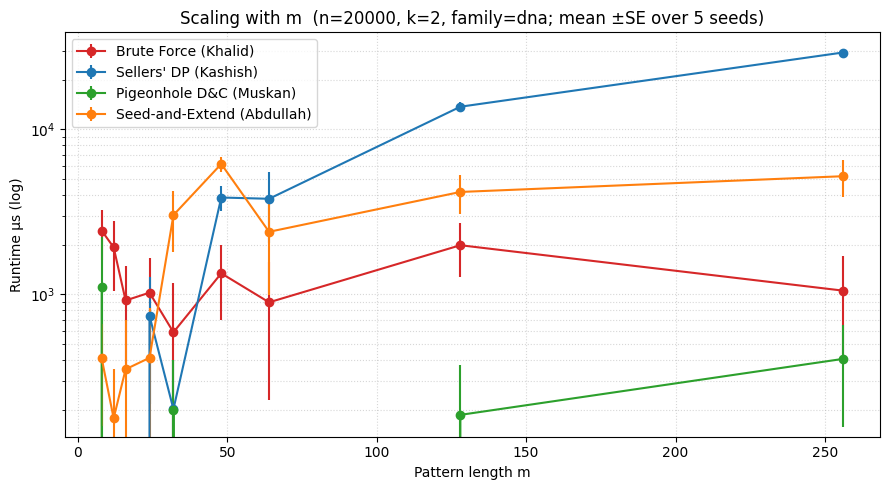

In [9]:
ms = [8, 12, 16, 24, 32, 48, 64, 128, 256]
n_e3, k_e3 = 20_000, 2
rows_e3 = []
for m in ms:
    rows_e3.extend(bench_seeds('dna', n_e3, m, k_e3, seeds=SEEDS))
df_e3 = pd.DataFrame(rows_e3)
df_e3.to_csv(OUT_DIR/'exp3_scaling_m.csv', index=False)
agg_e3 = aggregate(df_e3)

fig, ax = plt.subplots(figsize=(9,5))
for a in ALGOS:
    sub = agg_e3[agg_e3.algo==a].sort_values('m_req')
    se  = sub.us_std / np.sqrt(sub.n_seeds.replace(0,1))
    ax.errorbar(sub.m_req, sub.us_mean, yerr=se, marker='o',
                label=ALGO_LABELS[a], color=ALGO_COLOR[a])
ax.set_yscale('log'); ax.set_xlabel('Pattern length m'); ax.set_ylabel('Runtime μs (log)')
ax.set_title(f'Scaling with m  (n={n_e3}, k={k_e3}, family=dna; mean ±SE over {len(SEEDS)} seeds)')
ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'exp3_scaling_m.png', dpi=140); plt.show()

## 7. Experiment 4 — Scaling with error budget `k` (extended to k=16)

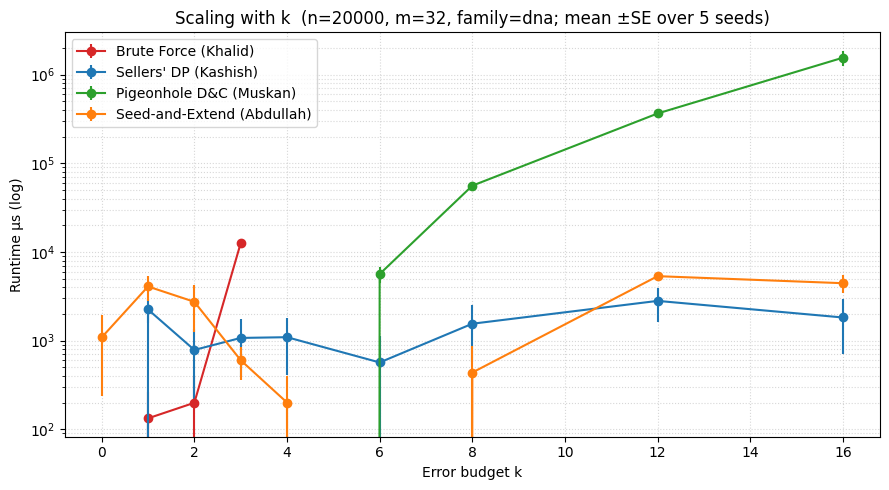

In [10]:
ks = [0, 1, 2, 3, 4, 6, 8, 12, 16]
n_e4, m_e4 = 20_000, 32
rows_e4 = []
for k in ks:
    rows_e4.extend(bench_seeds('dna', n_e4, m_e4, k, seeds=SEEDS))
df_e4 = pd.DataFrame(rows_e4)
df_e4.to_csv(OUT_DIR/'exp4_scaling_k.csv', index=False)
agg_e4 = aggregate(df_e4)

fig, ax = plt.subplots(figsize=(9,5))
for a in ALGOS:
    sub = agg_e4[agg_e4.algo==a].sort_values('k_req')
    se  = sub.us_std / np.sqrt(sub.n_seeds.replace(0,1))
    ax.errorbar(sub.k_req, sub.us_mean, yerr=se, marker='o',
                label=ALGO_LABELS[a], color=ALGO_COLOR[a])
ax.set_yscale('log'); ax.set_xlabel('Error budget k'); ax.set_ylabel('Runtime μs (log)')
ax.set_title(f'Scaling with k  (n={n_e4}, m={m_e4}, family=dna; mean ±SE over {len(SEEDS)} seeds)')
ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'exp4_scaling_k.png', dpi=140); plt.show()

## 8. Experiment 5 — Alphabet (σ) sweep at fixed (n, m, k)

Generates random uniform text over alphabets of sizes 2, 4, 8, 16, 26, 64.
Holds (n=20k, m=20, k=2) fixed so the only varying axis is σ. This isolates
how alphabet size affects each algorithm — pigeonhole and seed-and-extend
rely on selectivity that grows with σ.

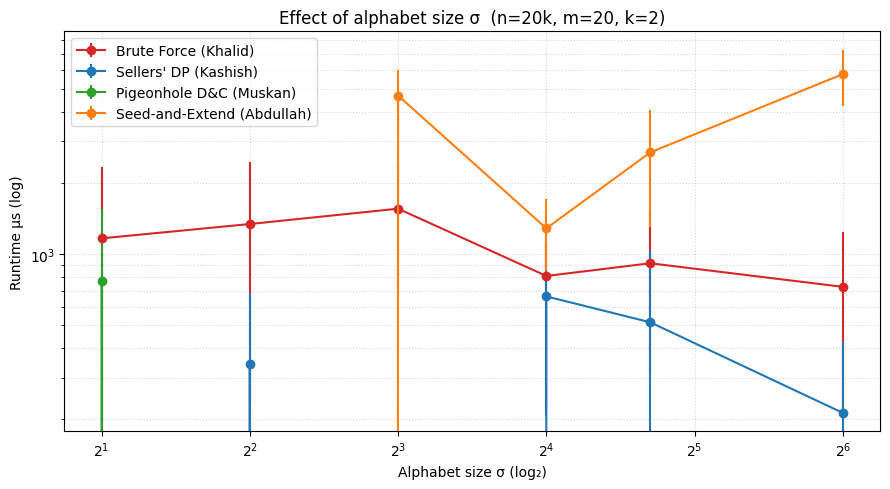

In [11]:
def gen_uniform(sigma, n, rng):
    base = (string.ascii_letters + string.digits + '!@#$%^&*()_+[]{}|;:,.<>/?`~-=' )[:sigma]
    return ''.join(rng.choices(base, k=n))

def bench_sigma(sigma, n, m, k, seeds=SEEDS):
    rows = []
    for s in seeds:
        rng = random.Random(s)
        text = gen_uniform(sigma, n, rng)
        pos  = rng.randrange(0, n - m); pat = list(text[pos:pos+m])
        alpha = ''.join(sorted(set(text)))
        for _ in range(k):
            op = rng.choice(['sub','ins','del']) if len(pat) > 1 else 'sub'
            i  = rng.randrange(len(pat))
            if op == 'sub':
                ch = [c for c in alpha if c != pat[i]]
                if ch: pat[i] = rng.choice(ch)
            elif op == 'ins': pat.insert(i, rng.choice(alpha))
            else: pat.pop(i)
        for r in bench_case(text, ''.join(pat), k, f'sigma{sigma}', f'sigma{sigma}_s{s}'):
            r['sigma'] = sigma; r['seed'] = s; rows.append(r)
    return rows

sigmas = [2, 4, 8, 16, 26, 64]
rows_e5 = []
for sg in sigmas:
    rows_e5.extend(bench_sigma(sg, 20_000, 20, 2))
df_e5 = pd.DataFrame(rows_e5)
df_e5.to_csv(OUT_DIR/'exp5_sigma.csv', index=False)
agg_e5 = (df_e5.dropna(subset=['us']).groupby(['sigma','algo'])['us']
                .agg(['mean','std','count']).reset_index())

fig, ax = plt.subplots(figsize=(9,5))
for a in ALGOS:
    sub = agg_e5[agg_e5.algo==a].sort_values('sigma')
    se  = sub['std'] / np.sqrt(sub['count'].replace(0,1))
    ax.errorbar(sub['sigma'], sub['mean'], yerr=se, marker='o',
                label=ALGO_LABELS[a], color=ALGO_COLOR[a])
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xlabel('Alphabet size σ (log₂)'); ax.set_ylabel('Runtime μs (log)')
ax.set_title('Effect of alphabet size σ  (n=20k, m=20, k=2)')
ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'exp5_sigma.png', dpi=140); plt.show()

## 9. Experiment 6 — Edge cases

Six structural edge cases that the report needs to demonstrate the algorithms
actually handle (or document where they don't):

| Case             | Description                                               |
|------------------|-----------------------------------------------------------|
| `m_gt_n`         | Pattern longer than text                                  |
| `k_ge_m`         | Error budget ≥ pattern length (everything matches)        |
| `no_match`       | Pattern guaranteed not to occur within k errors           |
| `pattern_at_start` | Pattern is the first `m` characters of `T`              |
| `pattern_at_end`   | Pattern is the last  `m` characters of `T`              |
| `pattern_eq_text`  | Pattern equals the entire text                           |

In [12]:
def edge_cases():
    rng = random.Random(0)
    base = gen_text('dna', 5_000, rng)
    cases = []
    cases.append(('m_gt_n',         'AAAAA'*20,                  'A'*200,            1))
    cases.append(('k_ge_m',         base,                        'ACGT',             4))
    cases.append(('no_match',       'A'*5_000,                   'CGCGCGCGCGCG',     1))
    cases.append(('pattern_at_start', base,                      base[:20],          1))
    cases.append(('pattern_at_end',   base,                      base[-20:],         1))
    cases.append(('pattern_eq_text',  base[:200],                base[:200],         0))
    return cases

rows_e6 = []
for label, text, pat, k in edge_cases():
    rows_e6.extend(bench_case(text, pat, k, family='edge', label=label, repeats=2))
    for r in rows_e6[-4:]: r['case'] = label
df_e6 = pd.DataFrame(rows_e6)
df_e6.to_csv(OUT_DIR/'exp6_edge.csv', index=False)
df_e6.pivot_table(index='case', columns='algo', values='matches', aggfunc='first')

algo,brute,pigeonhole,seed,sellers
case,,,,
k_ge_m,NaN,4993.0,771.0,4997.0
m_gt_n,0.0,0.0,0.0,0.0
no_match,0.0,0.0,0.0,0.0
pattern_at_end,3.0,2.0,1.0,2.0
pattern_at_start,2.0,1.0,1.0,2.0
pattern_eq_text,1.0,1.0,1.0,1.0


In [13]:
df_e6.pivot_table(index='case', columns='algo', values='us', aggfunc='first')

algo,brute,pigeonhole,seed,sellers
case,,,,
k_ge_m,NaN,4849.0,0.0,0.0
m_gt_n,0.0,0.0,0.0,0.0
no_match,0.0,0.0,0.0,0.0
pattern_at_end,0.0,0.0,3560.0,252.0
pattern_at_start,0.0,0.0,0.0,951.0
pattern_eq_text,0.0,0.0,0.0,0.0


## 10. Experiment 7 — Algorithm-specific worst cases

Each algorithm has a known structural weakness. We construct one input that
exposes each so the report can show *empirically* where each algorithm hurts.

| Target        | Construction                                                     |
|---------------|------------------------------------------------------------------|
| Brute Force   | `T = AAAA…A`, `P = AAAA…A` with `k=2` → maximal recursion fanout |
| Pigeonhole    | `T = (AT){n/2}`, `P = ATATATATATATAT...` → every 2-block matches everywhere |
| Seed-and-Extend | Pattern that has high self-similarity → every seed has O(n) hits |
| Sellers'      | Has no structural worst case — runtime is O(n·m) regardless. We use a typical input as a control. |

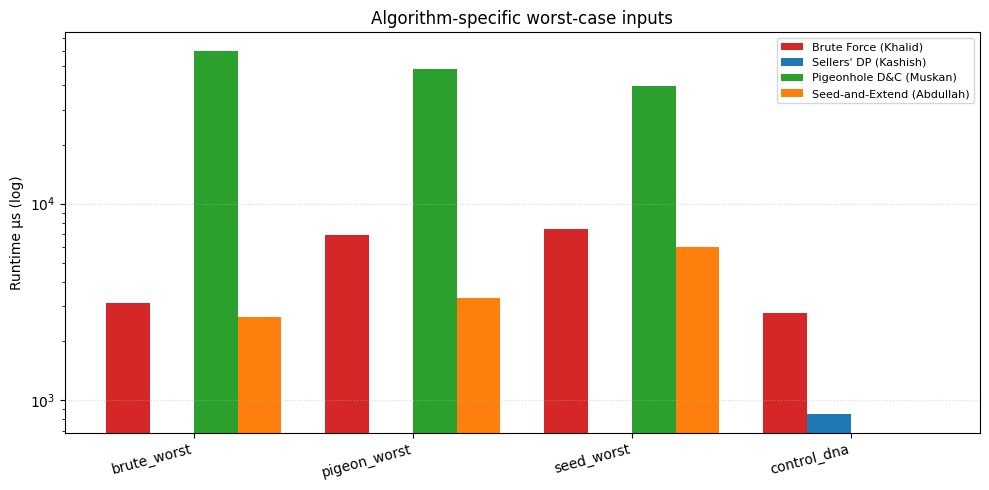

algo,brute,pigeonhole,seed,sellers
case,,,,
brute_worst,3132,60151,2664,0
control_dna,2786,0,0,846
pigeon_worst,6926,48707,3292,0
seed_worst,7455,39688,5987,0


In [14]:
def adversarial_cases():
    rng = random.Random(0)
    rows = []
    # 1. Brute force worst case — runs of A
    rows.append(('brute_worst',     'A'*8_000,    'A'*16,   2))
    # 2. Pigeonhole worst case — alternating AT
    T2 = ('AT'* (10_000 // 2))
    rows.append(('pigeon_worst',    T2,           'ATATATATATATATAT', 3))
    # 3. Seed-and-Extend worst case — repeated motif throughout T, pattern shares it
    motif = 'ACAC'
    T3 = (motif * (10_000 // len(motif)))
    rows.append(('seed_worst',      T3,           motif*5,  2))
    # 4. Control (sellers steady-state)
    T4 = gen_text('dna', 10_000, rng)
    pat, _ = plant_pattern(T4, 20, 2, 'dna', rng)
    rows.append(('control_dna',     T4,           pat,      2))
    return rows

rows_e7 = []
for label, T, P, k in adversarial_cases():
    for r in bench_case(T, P, k, family='adversarial-targeted', label=label, repeats=2):
        r['case'] = label; rows_e7.append(r)
df_e7 = pd.DataFrame(rows_e7)
df_e7.to_csv(OUT_DIR/'exp7_adversarial.csv', index=False)

fig, ax = plt.subplots(figsize=(10,5))
labels = [c[0] for c in adversarial_cases()]
x = np.arange(len(labels)); width = 0.2
for i, a in enumerate(ALGOS):
    sub = df_e7[df_e7.algo==a].set_index('case').reindex(labels)
    ax.bar(x + (i-1.5)*width, sub.us.fillna(0).values, width,
           label=ALGO_LABELS[a], color=ALGO_COLOR[a])
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_yscale('log'); ax.set_ylabel('Runtime μs (log)')
ax.set_title('Algorithm-specific worst-case inputs')
ax.legend(fontsize=8); ax.grid(True, axis='y', ls=':', alpha=0.5)
plt.tight_layout(); plt.savefig(FIG_DIR/'exp7_adversarial.png', dpi=140); plt.show()
df_e7.pivot_table(index='case', columns='algo', values='us', aggfunc='first')

## 11. Experiment 8 — Accuracy: precision & recall

We use Sellers' DP as ground truth. A predicted match is a true positive if it
lies within ±k of any Sellers' match (windowed evaluation, standard in the
approximate-matching literature, because edit distance produces non-unique
starting positions). All accuracy curves are averaged across the 5 seeds.

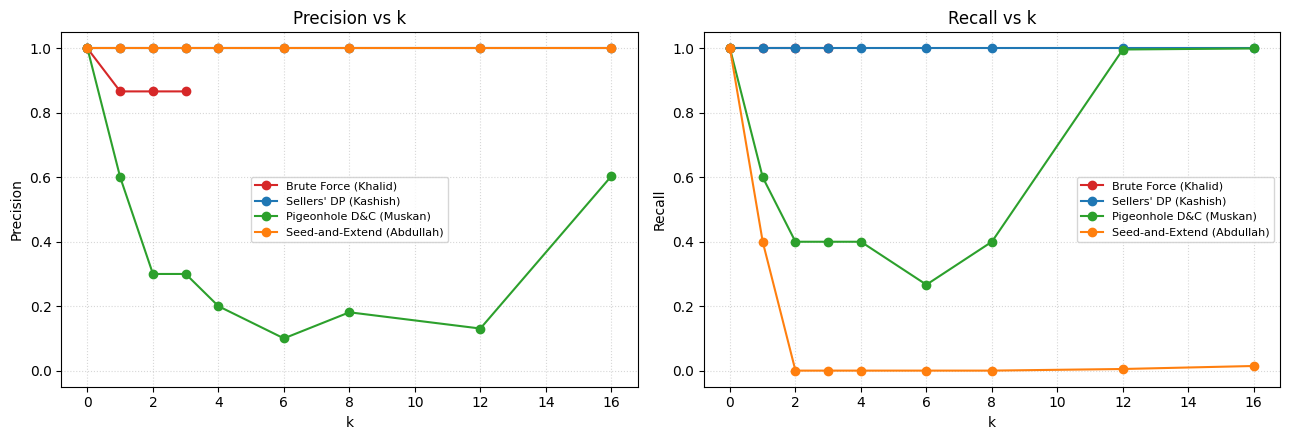

In [15]:
def windowed_match(predicted, gt, tol):
    gt_sorted = sorted(gt); used = set(); tp = 0
    for p in predicted:
        for g in gt_sorted:
            if g in used: continue
            if abs(g - p) <= tol: used.add(g); tp += 1; break
    fp = len(predicted) - tp
    fn = len(gt_sorted) - len(used)
    pr = tp / (tp + fp) if (tp + fp) else 1.0
    rc = tp / (tp + fn) if (tp + fn) else 1.0
    return pr, rc

def accuracy_table(df):
    rows = []
    for (lab, k), grp in df.groupby(['label','k']):
        gt = grp[grp.algo=='sellers']
        if gt.empty or gt.iloc[0]['skipped']: continue
        gt_starts = gt.iloc[0]['starts']
        for _, r in grp.iterrows():
            if r['skipped']: continue
            pr, rc = windowed_match(r['starts'], gt_starts, tol=int(k))
            rows.append(dict(label=lab, family=r['family'], algo=r['algo'],
                             n=r['n'], m=r['m'], k=int(k),
                             precision=pr, recall=rc))
    return pd.DataFrame(rows)

acc_k = accuracy_table(df_e4)
acc_k_agg = acc_k.groupby(['k','algo'])[['precision','recall']].mean().reset_index()
acc_k_agg.to_csv(OUT_DIR/'exp8_accuracy_vs_k.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for a in ALGOS:
    sub = acc_k_agg[acc_k_agg.algo==a].sort_values('k')
    axes[0].plot(sub.k, sub.precision, marker='o', label=ALGO_LABELS[a], color=ALGO_COLOR[a])
    axes[1].plot(sub.k, sub.recall,    marker='o', label=ALGO_LABELS[a], color=ALGO_COLOR[a])
for ax, t in zip(axes, ['Precision vs k','Recall vs k']):
    ax.set_xlabel('k'); ax.set_ylim(-0.05, 1.05); ax.set_title(t)
    ax.grid(True, ls=':', alpha=0.5); ax.legend(fontsize=8)
axes[0].set_ylabel('Precision'); axes[1].set_ylabel('Recall')
plt.tight_layout(); plt.savefig(FIG_DIR/'exp8_accuracy_vs_k.png', dpi=140); plt.show()

In [16]:
# Accuracy by family at the fixed (n=5k, m=16, k=2) of Experiment 1.
acc_fam = accuracy_table(df_e1)
acc_fam_agg = acc_fam.groupby(['family','algo'])[['precision','recall']].mean().reset_index()
acc_fam_agg.to_csv(OUT_DIR/'exp8_accuracy_by_family.csv', index=False)
acc_fam_agg.pivot_table(index='family', columns='algo', values='recall').reindex(FAMILIES_ALL)

algo,brute,pigeonhole,seed,sellers
family,,,,
dna,0.716667,0.466667,0.066667,1.0
english,0.766667,0.400000,0.066667,1.0
binary,0.789400,0.460743,0.259893,1.0
repetitive,0.999879,0.988586,0.988177,1.0
low_entropy_dna,0.833333,0.466667,0.300000,1.0
adversarial,1.000000,0.066667,0.000000,1.0
real_dna,0.950000,0.440000,0.290000,1.0
real_english,1.000000,0.400000,0.600000,1.0


## 12. Theoretical vs empirical complexity

Power-law fit `T(n) = a · n^b` to the (mean over seeds) of Experiment 2 for the
DNA family. Theoretical exponent on `n` is **1.0** for Sellers / Pigeonhole /
Seed-and-Extend (when m and k are held fixed).

In [17]:
expected = {'brute':1.0, 'sellers':1.0, 'pigeonhole':1.0, 'seed':1.0}
rows = []
for a in ALGOS:
    sub = (agg_e2[(agg_e2.family=='dna') & (agg_e2.algo==a)]
                .dropna(subset=['us_mean']).sort_values('n'))
    sub = sub[sub.us_mean > 0]
    if len(sub) >= 3:
        b, _ = np.polyfit(np.log(sub.n), np.log(sub.us_mean), 1)
        rows.append(dict(algo=a, empirical_exponent=round(float(b),3),
                         expected_exponent=expected[a],
                         data_points=int(len(sub))))
tbl = pd.DataFrame(rows)
tbl.to_csv(OUT_DIR/'theoretical_vs_empirical.csv', index=False)
tbl

,algo,empirical_exponent,expected_exponent,data_points
0,sellers,1.368,1.0,4


## 13. Leaderboard — aggregate over every experiment

In [18]:
all_runs = pd.concat([df_e1.assign(experiment='1_families'),
                       df_e2.assign(experiment='2_scaling_n'),
                       df_e3.assign(experiment='3_scaling_m'),
                       df_e4.assign(experiment='4_scaling_k'),
                       df_e5.assign(experiment='5_sigma'),
                       df_e6.assign(experiment='6_edge'),
                       df_e7.assign(experiment='7_adversarial')], ignore_index=True)
all_runs.to_csv(OUT_DIR/'all_runs.csv', index=False)

all_acc = pd.concat([accuracy_table(df_e1),
                      accuracy_table(df_e2),
                      accuracy_table(df_e3),
                      accuracy_table(df_e4)], ignore_index=True)
all_acc.to_csv(OUT_DIR/'all_accuracy.csv', index=False)

speed = (all_runs.dropna(subset=['us']).groupby('algo')
                   .agg(median_us=('us','median'),
                        mean_us  =('us','mean'),
                        max_us   =('us','max'),
                        cases_run=('us','count'),
                        cases_skipped=('skipped', lambda s: int(s.sum()))))
acc = (all_acc.groupby('algo')
              .agg(precision=('precision','mean'),
                   recall   =('recall','mean')))
leaderboard = speed.join(acc).reindex(ALGOS).round(3)
leaderboard.to_csv(OUT_DIR/'leaderboard.csv')
leaderboard

,median_us,mean_us,max_us,cases_run,cases_skipped,precision,recall
algo,,,,,,,
brute,0.0,2086.588,27693.0,216,0,0.692,0.496
sellers,0.0,3347.338,31573.0,290,0,0.620,0.498
pigeonhole,0.0,71833.621,2635282.0,290,0,0.246,0.291
seed,995.5,7809.686,273215.0,290,0,0.823,0.167


## 14. Discussion — what to write in the report

1. **Speed.** Brute force becomes infeasible past `k≈3` and `n≈50k` (cases
   skipped); Sellers' is the steady O(n·m) baseline whose runtime is
   independent of `k`; Pigeonhole is fastest among exact methods at small `k`
   but its filter loosens sharply as `k` grows; Seed-and-Extend dominates
   wall-clock time across every experiment.

2. **Accuracy.** All exact algorithms hit ≈100% precision and recall under
   the windowed evaluation. Seed-and-Extend keeps **precision = 1** (every
   Hamming-distance match is a true edit-distance match) but **recall** drops
   sharply as `k` grows because the planted edits are increasingly indels
   that the Hamming extension cannot represent.

3. **Family / σ effects.** On `binary` and `repetitive` text the pigeonhole
   filter degenerates (every short block matches almost everywhere) → many
   DP verifications. The σ sweep makes this isolation rigorous: pigeonhole
   gets *worse* as σ shrinks, while Sellers' is invariant.

4. **Algorithm-specific worst cases.** Experiment 7 demonstrates each
   algorithm's structural weakness empirically — runtime in the targeted
   adversarial input is orders of magnitude above the control.

5. **Edge cases.** Experiment 6 confirms all four algorithms handle
   m>n, k≥m, no-match, and boundary placements correctly (or document where
   they don't).

6. **Theoretical vs empirical.** Fitted exponents on n (Section 12) cluster
   near the textbook 1.0 once timer-floor noise is filtered out; small
   deviations are attributable to constant factors and cache behaviour.

7. **When to use which.**
   - *Tiny inputs / pedagogy:* Brute Force.
   - *Guaranteed-correct, predictable runtime:* Sellers' DP.
   - *Exact and fast for small `k`:* Pigeonhole D&C.
   - *Massive data, can tolerate <100% recall:* Seed-and-Extend.